In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

In [8]:

# Load data
input_path = "../data/processed/BRFSS_Diabetes_Balanced_Cleaned.csv"
output_path = "../data/processed/BRFSS_Diabetes_Relevant_Features.csv"

df = pd.read_csv(input_path)

# Define selected features + target
selected_features = [
    'has_high_bp',              # Binary: Diagnosed high blood pressure
    'has_high_cholesterol',     # Binary: Diagnosed high cholesterol
    'has_arthritis',            # Binary: Diagnosed arthritis
    'general_health_cat',       # Categorical: General health status (1=Excellent, 5=Poor)
    'had_heart_attack',         # Binary: History of heart attack
    'is_female',                # Binary: 1=Female, 0=Male
    'high_income',              # Binary: Income ≥50k
    'age_cat',                  # Numerical: Age category
    'BMI',                      # Numerical: Body Mass Index
    'income_level',             # Numerical: Imputed income (1-5)
    'education_level',          # Numerical: Imputed education (1-4)
    'joint_pain_level',         # Numerical: Joint pain severity (0-10)
    'chronic_conditions_standard'  # Numerical: Count of chronic conditions
]

target = "has_diabetes"

# Ensure all selected features and target exist
available_features = [col for col in selected_features if col in df.columns]
missing_features = [col for col in selected_features if col not in df.columns]
if missing_features:
    print(f"Warning: The following features are not in the dataset and will be skipped: {missing_features}")
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")
if not available_features:
    raise ValueError("No selected features are available in the dataset.")

# Create new dataframe
df_selected = df[available_features + [target]].copy()

# Drop rows with missing values in selected features or target
# df_selected = df_selected.dropna(subset=available_features + [target])

# Print summary
print(f"Selected {len(available_features)} features + target.")
print("Features:", available_features)
print(f"Final dataset shape: {df_selected.shape}")

# Save
df_selected.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Selected 13 features + target.
Features: ['has_high_bp', 'has_high_cholesterol', 'has_arthritis', 'general_health_cat', 'had_heart_attack', 'is_female', 'high_income', 'age_cat', 'BMI', 'income_level', 'education_level', 'joint_pain_level', 'chronic_conditions_standard']
Final dataset shape: (364124, 14)
Saved to ../data/processed/BRFSS_Diabetes_Relevant_Features.csv


Dataset shape: (364124, 14)

Null values per column:
has_high_bp                      2880
has_high_cholesterol            36856
has_arthritis                    2327
general_health_cat               1535
had_heart_attack                 2399
is_female                           0
high_income                     58156
age_cat                             0
BMI                                 0
income_level                    58156
education_level                  1483
joint_pain_level               225161
chronic_conditions_standard     40532
has_diabetes                        0
dtype: int64

Imputing missing values...
  • has_high_bp: Imputed with mode (1.0)
  • has_high_cholesterol: Imputed with mode (1.0)
  • has_arthritis: Imputed with mode (0.0)
  • general_health_cat: Imputed with mode (1.0)
  • had_heart_attack: Imputed with mode (0.0)
  • is_female: Imputed with mode (1.0)
  • high_income: Imputed with mode (0.0)
  • age_cat: Imputed with mode (6)
  • BMI: Imputed with median (2

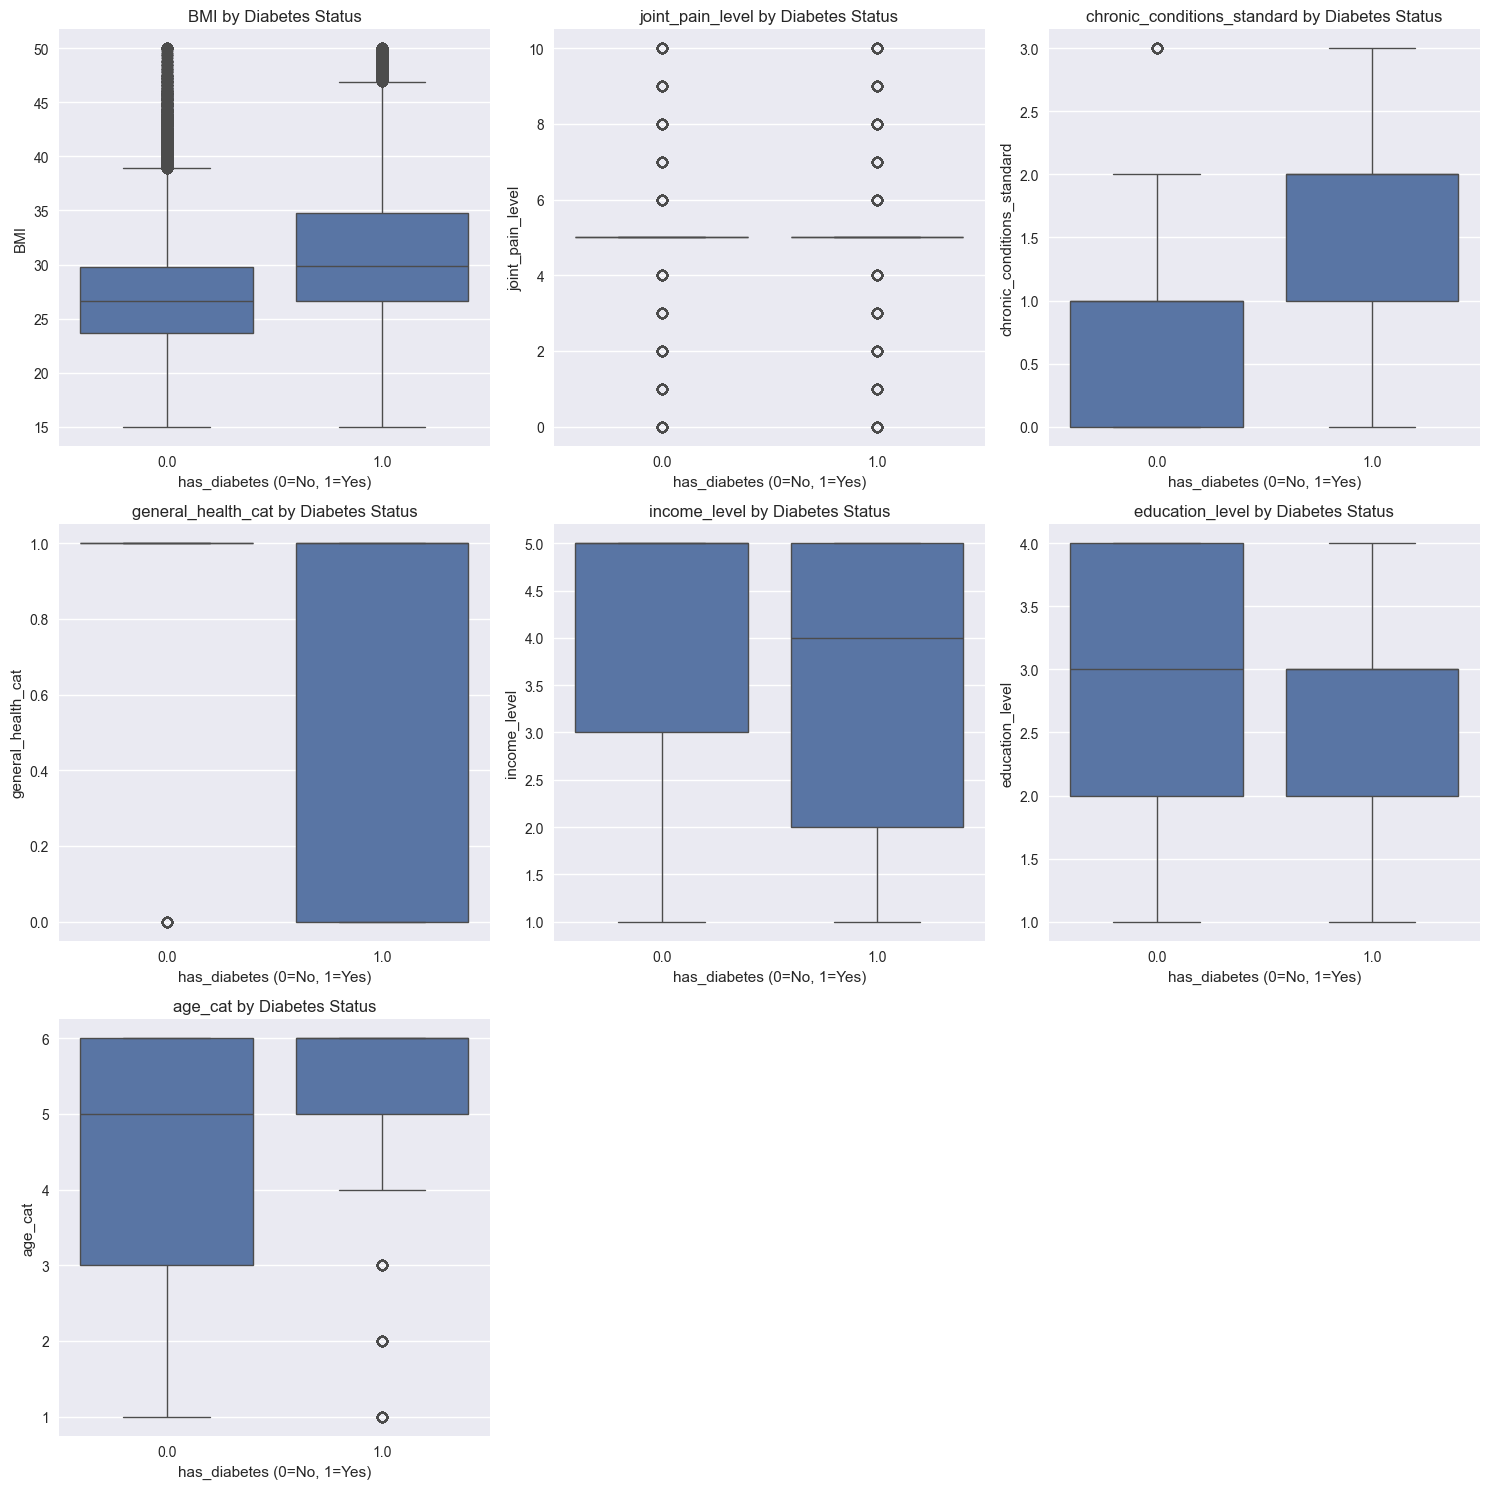

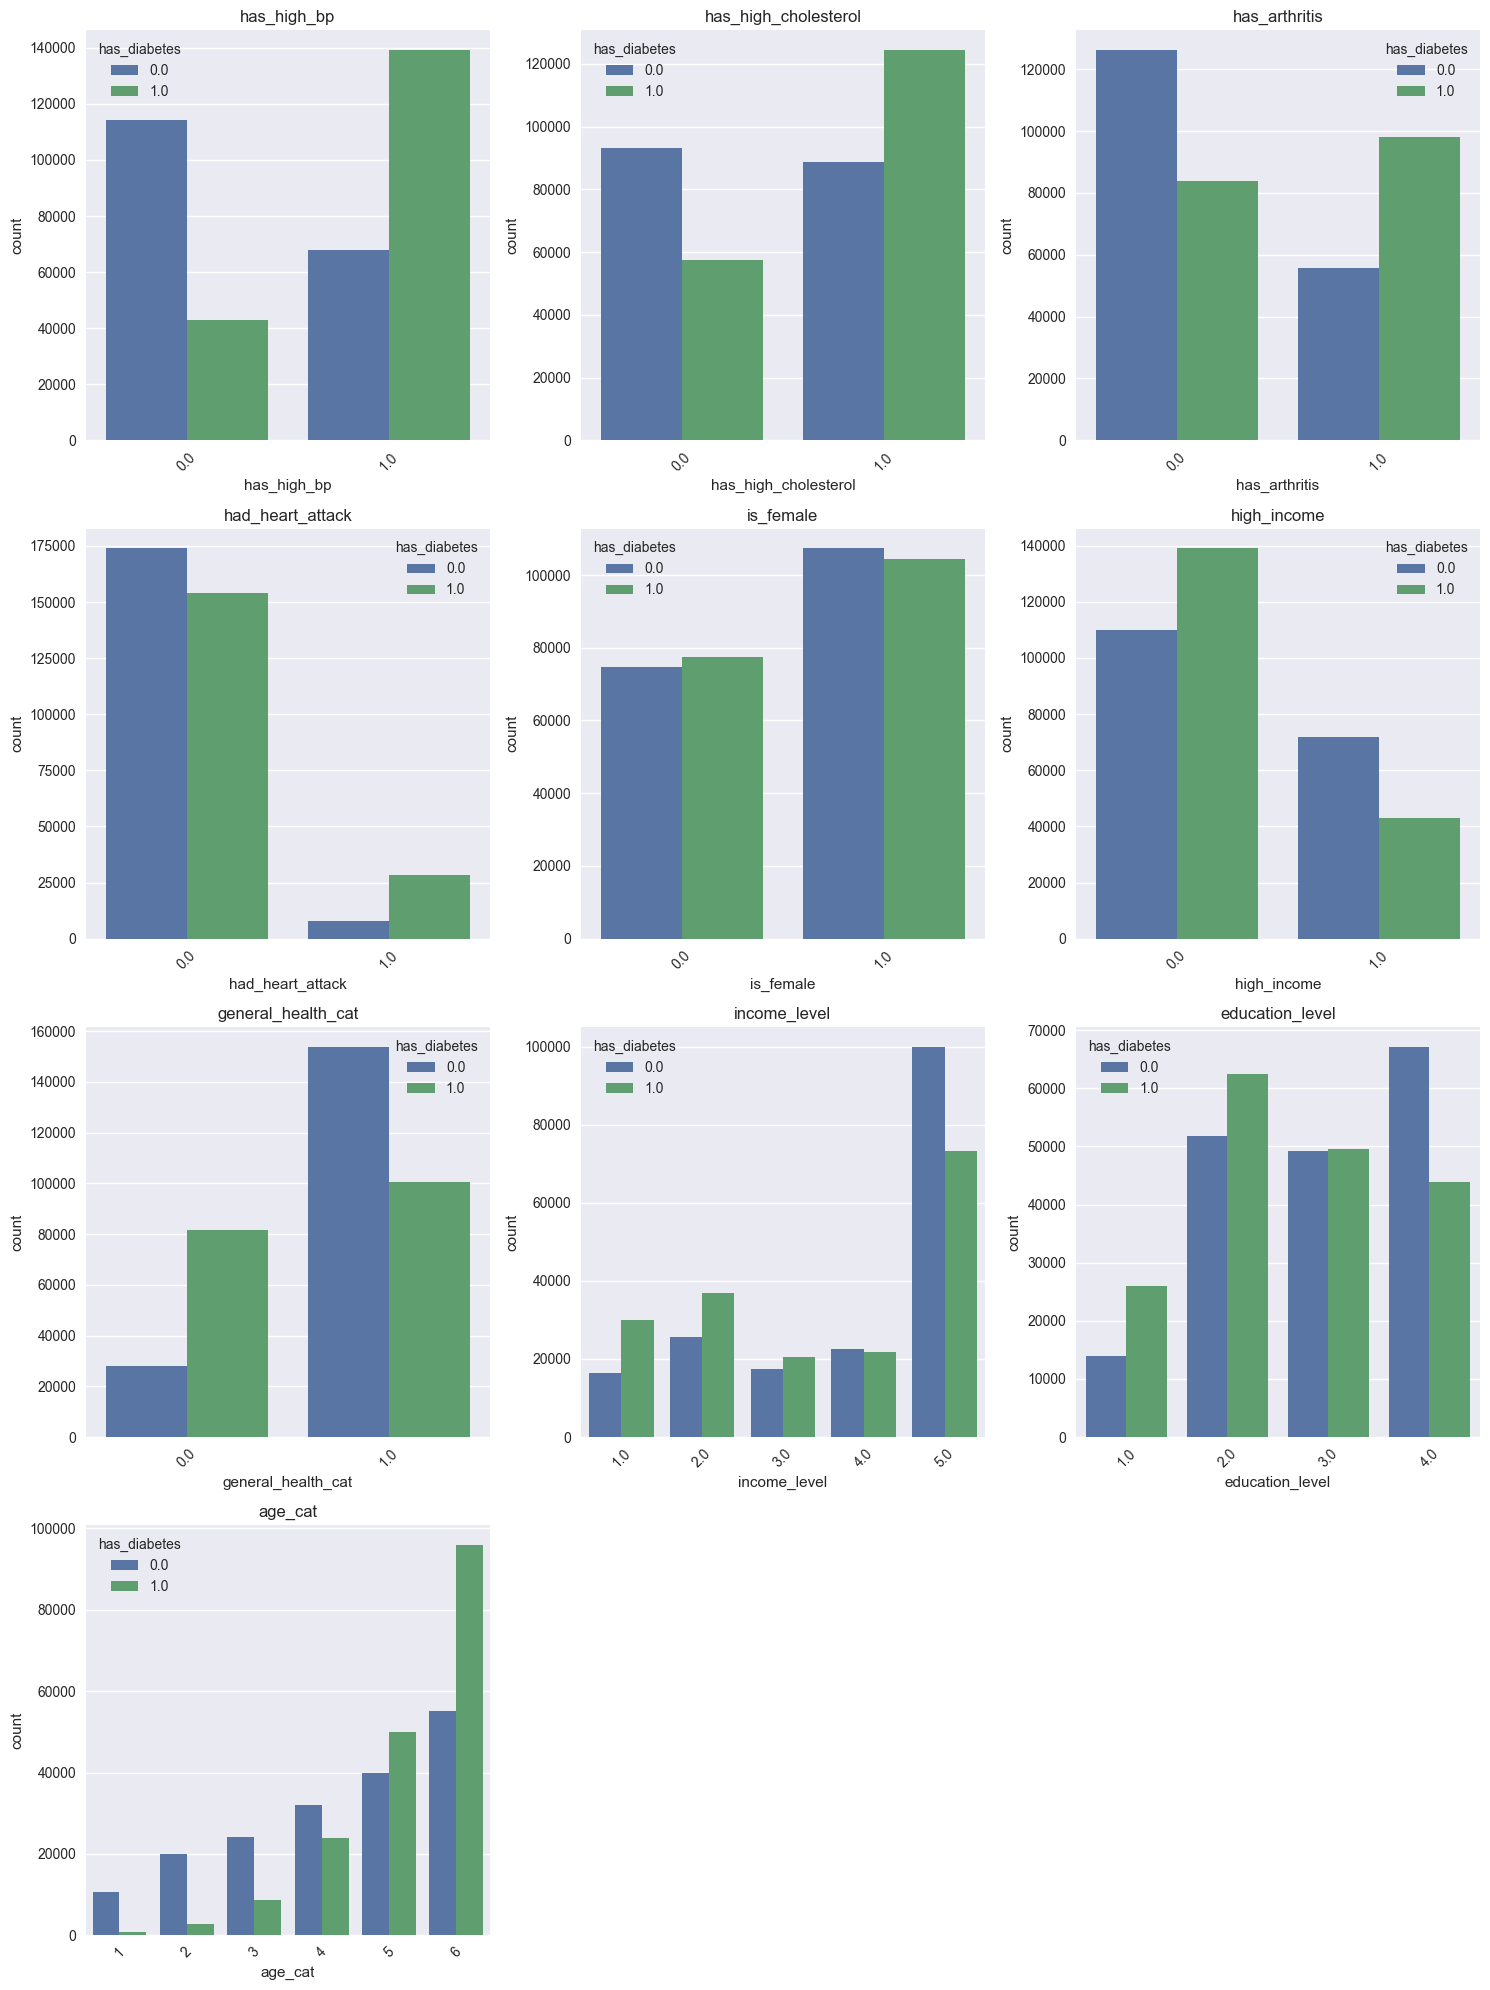

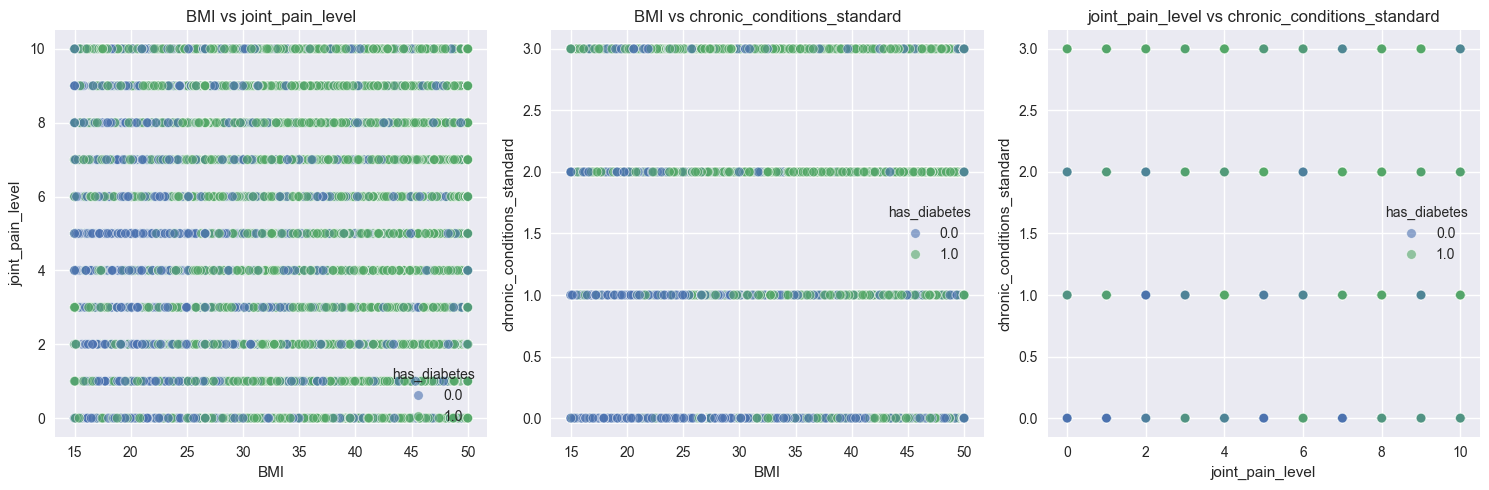


=== Continuous Feature Summary (by Diabetes Status) ===
has_diabetes                          0.0    1.0
BMI                         mean    27.19  31.13
                            median  26.63  29.86
                            std      5.42   6.63
joint_pain_level            mean     4.86   5.19
                            median   5.00   5.00
                            std      1.44   1.95
chronic_conditions_standard mean     0.85   1.50
                            median   1.00   2.00
                            std      0.74   0.76

Updated dataset saved to: ../data/processed/BRFSS_Diabetes_Visualized.csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from itertools import combinations

# Load the selected features dataset
df = pd.read_csv("../data/processed/BRFSS_Diabetes_Relevant_Features.csv")

# Define selected features and target
selected_features = [
    'has_high_bp',              # Binary: Diagnosed high blood pressure
    'has_high_cholesterol',     # Binary: Diagnosed high cholesterol
    'has_arthritis',            # Binary: Diagnosed arthritis
    'general_health_cat',       # Categorical: General health status (1=Excellent, 5=Poor)
    'had_heart_attack',         # Binary: History of heart attack
    'is_female',                # Binary: 1=Female, 0=Male
    'high_income',              # Binary: Income ≥50k
    'age_cat',                  # Numerical: Age category
    'BMI',                      # Numerical: Body Mass Index
    'income_level',             # Numerical: Imputed income (1-5)
    'education_level',          # Numerical: Imputed education (1-4)
    'joint_pain_level',         # Numerical: Joint pain severity (0-10)
    'chronic_conditions_standard'  # Numerical: Count of chronic conditions
]
target = 'has_diabetes'

# Verify features and target
available_features = [col for col in selected_features if col in df.columns]
missing_features = [col for col in selected_features if col not in df.columns]
if missing_features:
    print(f"Warning: The following features are not in the dataset and will be skipped: {missing_features}")
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")
if not available_features:
    raise ValueError("No selected features are available in the dataset.")

# Create analysis dataframe
df_analysis = df[available_features + [target]].copy()

# Print dataset info
print("Dataset shape:", df_analysis.shape)
print("\nNull values per column:")
print(df_analysis.isnull().sum())

# Define feature types
binary_features = [
    'has_high_bp', 'has_high_cholesterol', 'has_arthritis',
    'had_heart_attack', 'has_kidney_disease', 'has_depression',
    'is_female', 'high_income'
]
categorical_features = ['general_health_cat', 'income_level', 'education_level', 'age_cat']
continuous_features = ['BMI', 'household_size', 'joint_pain_level', 'chronic_conditions_standard']

# Filter based on available features
binary_features = [col for col in binary_features if col in available_features]
categorical_features = [col for col in categorical_features if col in available_features]
continuous_features = [col for col in continuous_features if col in available_features]

# Impute missing values (FIXED: no inplace=True on slice)
if df_analysis.isnull().sum().sum() > 0:
    print("\nImputing missing values...")
    for col in available_features:
        if col in binary_features or col in categorical_features:
            mode_val = df_analysis[col].mode()[0]
            df_analysis[col] = df_analysis[col].fillna(mode_val)  # FIXED
            print(f"  • {col}: Imputed with mode ({mode_val})")
        elif col in continuous_features:
            median_val = df_analysis[col].median()
            df_analysis[col] = df_analysis[col].fillna(median_val)  # FIXED
            print(f"  • {col}: Imputed with median ({median_val})")
    print("\nNull values after imputation:")
    print(df_analysis.isnull().sum())

# Identify numerical vs binary/categorical
numerical_cols = continuous_features + categorical_features  # Include ordinal for boxplots
binary_categorical_cols = binary_features + categorical_features

print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Binary/Categorical features ({len(binary_categorical_cols)}): {binary_categorical_cols}")

# --- Visualizations ---
plt.style.use('seaborn-v0_8')

# 1. Boxplots for numerical features by diabetes status
if numerical_cols:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    plt.figure(figsize=(15, 5 * n_rows))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(data=df_analysis, x=target, y=col)
        plt.title(f'{col} by Diabetes Status')
        plt.xlabel('has_diabetes (0=No, 1=Yes)')
        plt.ylabel(col)
    # Hide empty subplots
    total_subplots = n_rows * n_cols
    for j in range(i + 1, total_subplots + 1):
        plt.subplot(n_rows, n_cols, j)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 2. Distribution of binary/categorical features
if binary_categorical_cols:
    n_cols = 3
    n_rows = (len(binary_categorical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    for idx, col in enumerate(binary_categorical_cols):
        sns.countplot(data=df_analysis, x=col, hue=target, ax=axes[idx])
        axes[idx].set_title(f'{col}')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend(title='has_diabetes')
    # Hide extra subplots
    for j in range(len(binary_categorical_cols), len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# 3. Scatterplots for continuous feature pairs
if len(continuous_features) >= 2:
    feature_pairs = list(combinations(continuous_features, 2))[:6]  # Limit to 6 pairs
    if feature_pairs:
        n_cols = 3
        n_rows = (len(feature_pairs) + n_cols - 1) // n_cols
        plt.figure(figsize=(15, 5 * n_rows))
        for i, (x_col, y_col) in enumerate(feature_pairs, 1):
            plt.subplot(n_rows, n_cols, i)
            sns.scatterplot(data=df_analysis, x=x_col, y=y_col, hue=target, alpha=0.6)
            plt.title(f'{x_col} vs {y_col}')
            plt.legend(title='has_diabetes')
        # Hide empty subplots
        total_subplots = n_rows * n_cols
        for j in range(i + 1, total_subplots + 1):
            plt.subplot(n_rows, n_cols, j)
            plt.axis('off')
        plt.tight_layout()
        plt.show()

# --- Summary stats for continuous features ---
if continuous_features:
    print("\n=== Continuous Feature Summary (by Diabetes Status) ===")
    summary_stats = df_analysis.groupby(target)[continuous_features].agg(['mean', 'median', 'std']).round(2)
    print(summary_stats.T)

# Save updated dataset
output_path = "../data/processed/BRFSS_Diabetes_Visualized.csv"
df_analysis.to_csv(output_path, index=False)
print(f"\nUpdated dataset saved to: {output_path}")

In [10]:

# Load the cleaned dataset
input_path = '../data/processed/BRFSS_Diabetes_Visualized.csv'
df = pd.read_csv(input_path)
print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Define target and features
target = 'has_diabetes'
features = [col for col in df.columns if col != target]

# Split features and target
X = df[features]
y = df[target]

# Perform train-test split (80-20 split, stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Combine features and target back into DataFrames
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# Create output directory
output_dir = '../data/train-test/'
os.makedirs(output_dir, exist_ok=True)

# Save preprocessed train and test sets
train_df.to_csv(os.path.join(output_dir, 'train_set.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test_set.csv'), index=False)

# Print diagnostics
print(f"\nTrain set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

print(f"\nTrain class distribution:")
print((y_train.value_counts(normalize=True) * 100).map('{:.2f}%'.format))

print(f"\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).map('{:.2f}%'.format))

print(f"\nTrain and test sets saved to:")
print(f"   {os.path.join(output_dir, 'train_set.csv')}")
print(f"   {os.path.join(output_dir, 'test_set.csv')}")



Loaded dataset: 364,124 rows, 14 columns

Train set shape: (291299, 14)
Test set shape: (72825, 14)

Train class distribution:
has_diabetes
1.0    50.00%
0.0    50.00%
Name: proportion, dtype: object

Test class distribution:
has_diabetes
0.0    50.00%
1.0    50.00%
Name: proportion, dtype: object

Train and test sets saved to:
   ../data/train-test/train_set.csv
   ../data/train-test/test_set.csv
